# Postprocesamiento y Análisis de Campañas

## 1. Conexión, Librerías y Carga de Datos

In [35]:
import geopandas as gpd
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_style('whitegrid')

In [36]:
# Conexión a PostGIS 
DB_USER = "postgres"
DB_PASS = "postgres"
DB_HOST = "db"
DB_PORT = "5432"
DB_NAME = "agtech_db"

# Cadena de conexión
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

print("Conexión a DB establecida.")

Conexión a DB establecida.


In [37]:
# Cargar la capa final 'Grid_final'
GRID_FINAL_TABLE = "Grid_final" 

try:
    gdf_final = gpd.read_postgis(
        f'SELECT * FROM \"{GRID_FINAL_TABLE}\"', 
        con=engine, 
        geom_col="geometry"
    )
    print(f" Capa '{GRID_FINAL_TABLE}' cargada (ANCHO): {len(gdf_final)} hexágonos.")
except Exception as e:
    print(f" ERROR al cargar la tabla {GRID_FINAL_TABLE} (ANCHO): {e}")

# Cargar la capa "" para Boxplots/Histogramas
GRID_APILADA_TABLE = "soy_performance_2019_2021_2023"

try:
    gdf_apilada = gpd.read_postgis(
        f'SELECT * FROM \"{GRID_APILADA_TABLE}\"', 
        con=engine, 
        geom_col="geometry"
    )
    
    # Renombrar columnas para usar nombres consistentes en los plots
    gdf_apilada.rename(columns={
        'campaign_year': 'Campaña', 
        'performance_pct': 'Rendimiento_PCT'
    }, inplace=True)
    
    print(f" Capa apilada '{GRID_APILADA_TABLE}' cargada (LARGO): {len(gdf_apilada)} registros.")
    display(gdf_apilada.head(2))
    
except Exception as e:
    print(f" ERROR al cargar la tabla apilada {GRID_APILADA_TABLE}: {e}")

 Capa 'Grid_final' cargada (ANCHO): 10214 hexágonos.
 Capa apilada 'soy_performance_2019_2021_2023' cargada (LARGO): 30684 registros.


,h3_res12,Campaña,Rendimiento_PCT,geometry
0,8cc34d60508b3ff,2023,45.174797,POINT (-63.80658 -33.99027)
1,8cc34d6054613ff,2019,26.973471,POINT (-63.80590 -33.99256)


## 2. Análisis del Rendimiento por Campaña

In [5]:
# Preparación de datos para el análisis de rendimiento de MÚLTIPLES campañas

ORIGINAL_REN_COL = 'Rendimiento_PCT'
ORIGINAL_CAMPAÑA_COL = 'Campaña'

# 1. Seleccionar las columnas con los nombres originales
df_campana = gdf_apilada[[ORIGINAL_CAMPAÑA_COL, ORIGINAL_REN_COL]].copy()

# 3. Definir las variables que usarán los plots posteriores
REN_COL = 'Rendimiento_PCT'
CAMPAÑA_COL = 'Campaña'

# 4. Limpieza y preparación final
df_campana.dropna(subset=[REN_COL], inplace=True) 
df_campana[CAMPAÑA_COL] = df_campana[CAMPAÑA_COL].astype(str)

print(f" Análisis de distribución listo para {len(df_campana[CAMPAÑA_COL].unique())} campañas.")
print(f"Filas totales para análisis de rendimiento: {len(df_campana)}")
print("Distribución de datos por campaña:\n", df_campana[CAMPAÑA_COL].value_counts())
display(df_campana.head())

 Análisis de distribución listo para 3 campañas.
Filas totales para análisis de rendimiento: 30684
Distribución de datos por campaña:
 Campaña
2021    10249
2019    10241
2023    10194
Name: count, dtype: int64


,Campaña,Rendimiento_PCT
0,2023,45.174797
1,2019,26.973471
2,2019,30.463606
3,2019,20.181079
4,2023,67.971290


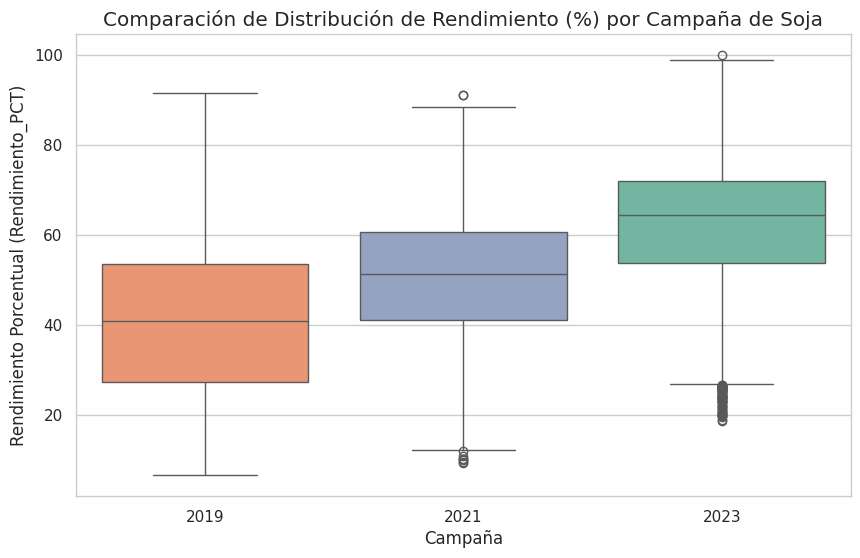

In [39]:
# --- 2.2. Boxplots para comparar el rendimiento entre campañas ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    x=CAMPAÑA_COL, 
    y=REN_COL, 
    data=df_campana, 
    hue=CAMPAÑA_COL,  # Se agrega hue para asignar colores por categoría
    palette="Set2", 
    order=['2019', '2021', '2023'],
    legend=False      # Se desactiva la leyenda redundante
)
plt.title('Comparación de Distribución de Rendimiento (%) por Campaña de Soja')
plt.xlabel('Campaña')
plt.ylabel('Rendimiento Porcentual (Rendimiento_PCT)')
plt.grid(True, axis='y')
plt.show()

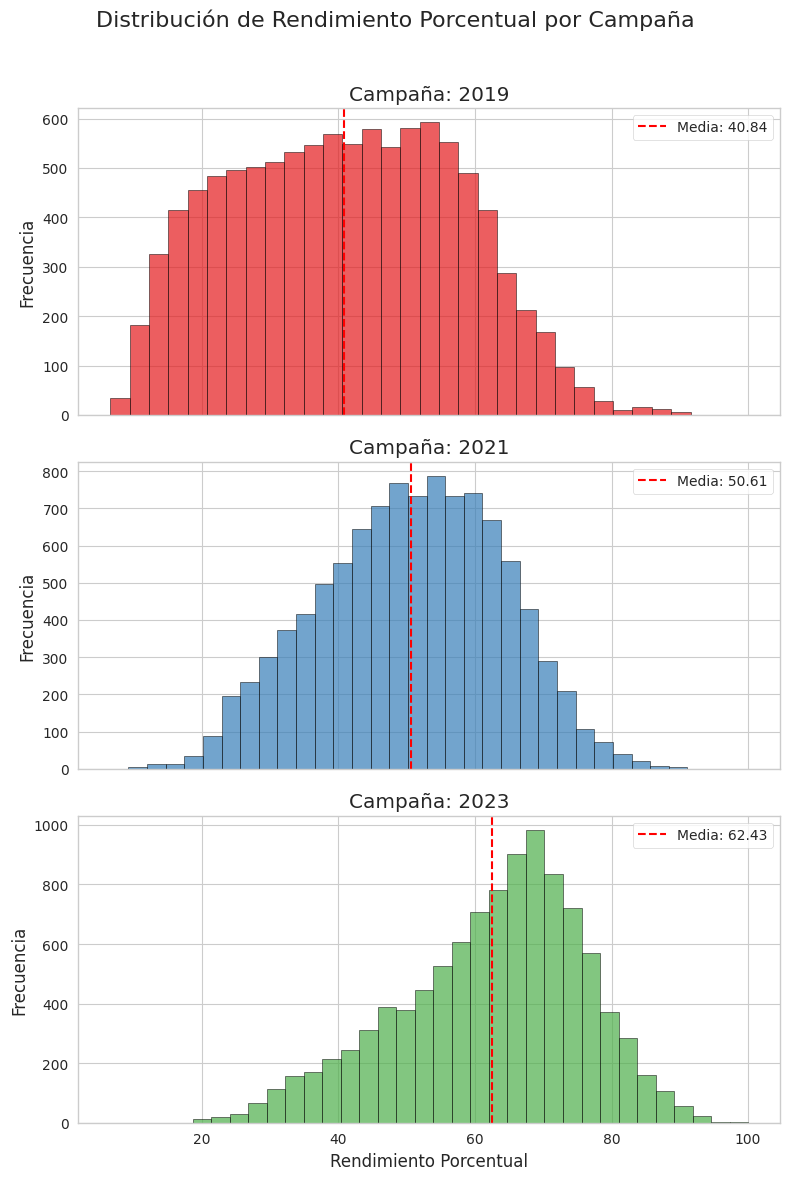

In [8]:
# Histogramas para visualizar la distribución del rendimiento 

campanas = df_campana[CAMPAÑA_COL].unique()
campanas.sort() 
num_campanas = len(campanas)

# Subplot por  campaña
fig, axes = plt.subplots(num_campanas, 1, figsize=(8, 4 * num_campanas), sharex=True)
fig.suptitle('Distribución de Rendimiento Porcentual por Campaña', fontsize=16)

for i, campana in enumerate(campanas):
    data_campana = df_campana[df_campana[CAMPAÑA_COL] == campana][REN_COL].dropna()
    
    ax = axes[i]
        
    # Graficar histograma con línea para la media
    ax.hist(
        data_campana, 
        bins=30, 
        edgecolor='black', 
        alpha=0.7, 
        color=sns.color_palette("Set1")[i % len(sns.color_palette("Set1"))]
    )
    ax.axvline(data_campana.mean(), color='red', linestyle='dashed', linewidth=1.5, label=f'Media: {data_campana.mean():.2f}')
    ax.set_title(f'Campaña: {campana}')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.xlabel(f'Rendimiento Porcentual')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Performance de las campañas: 
#### Al parecer la campaña 2023 está desplazada hacia la derecha (rendimientos altos) indicando que la mayoría de los hexágonos alcanzó un nivel de rendimiento superior al promedio. La Campaña 2021 es la más centrada, casi el 50% del lote se mantuvo entre rendimientos que oscilan entre 40 y 61. Por último, la campaña 2019 muestra un sesgo hacia la izquierda, con una gran concentración de sus rendimientos en valores bajos.

## 3. Preparación para Análisis de Correlación (CE y Altura)

In [9]:
# Nombres de todas las columnas de la tabla final
print("--- Columnas disponibles en gdf_final ---")
print(gdf_final.columns.tolist())

--- Columnas disponibles en gdf_final ---
['Empresa', 'Campania', 'Region', 'Campo', 'Lote', 'Actividad', 'Material', 'Area_lote', 'Hexagono', 'Id_Hexagono', 'Area_hexagono', 'Lat', 'Long', 'campaign_year_2019', 'performance_pct_2019', 'campaign_year_2021', 'performance_pct_2021', 'campaign_year_2023', 'performance_pct_2023', 'ec_surface', 'ec_subsurface', 'altimetry_rel', 'geometry']


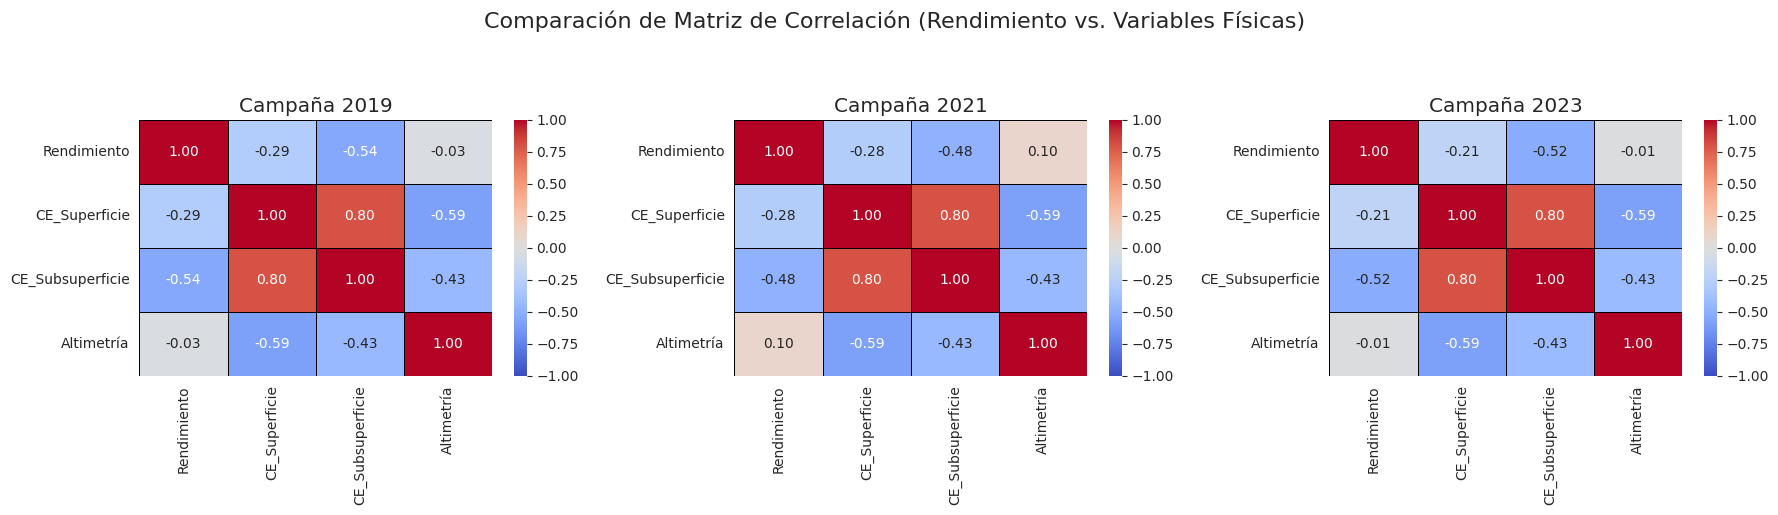

In [10]:
# Matrices de Correlación

STATIC_VARS = ['ec_surface', 'ec_subsurface', 'altimetry_rel']
CAMPAIGNS = {
    '2019': 'performance_pct_2019',
    '2021': 'performance_pct_2021',
    '2023': 'performance_pct_2023'
}
orden = ['2019', '2021', '2023']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Matriz de Correlación (Rendimiento vs. Variables Físicas)', fontsize=16, y=1.02)

for i, year in enumerate(orden):
    ren_col = CAMPAIGNS[year]
    cols_corr = [ren_col] + STATIC_VARS
    
    # 1. Preparar datos para el año actual
    df_corr = gdf_final[cols_corr].copy()
    df_corr.dropna(inplace=True)
    corr_matrix = df_corr.corr()
    
    # 2. Renombrar filas/columnas para que el heatmap sea limpio
    corr_matrix.columns = ['Rendimiento', 'CE_Superficie', 'CE_Subsuperficie', 'Altimetría']
    corr_matrix.index = ['Rendimiento', 'CE_Superficie', 'CE_Subsuperficie', 'Altimetría']

    # 3. Graficar
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        linewidths=.5, 
        linecolor='black', 
        ax=axes[i],
        vmin=-1, vmax=1 # Escala consistente
    )
    axes[i].set_title(f'Campaña {year}')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

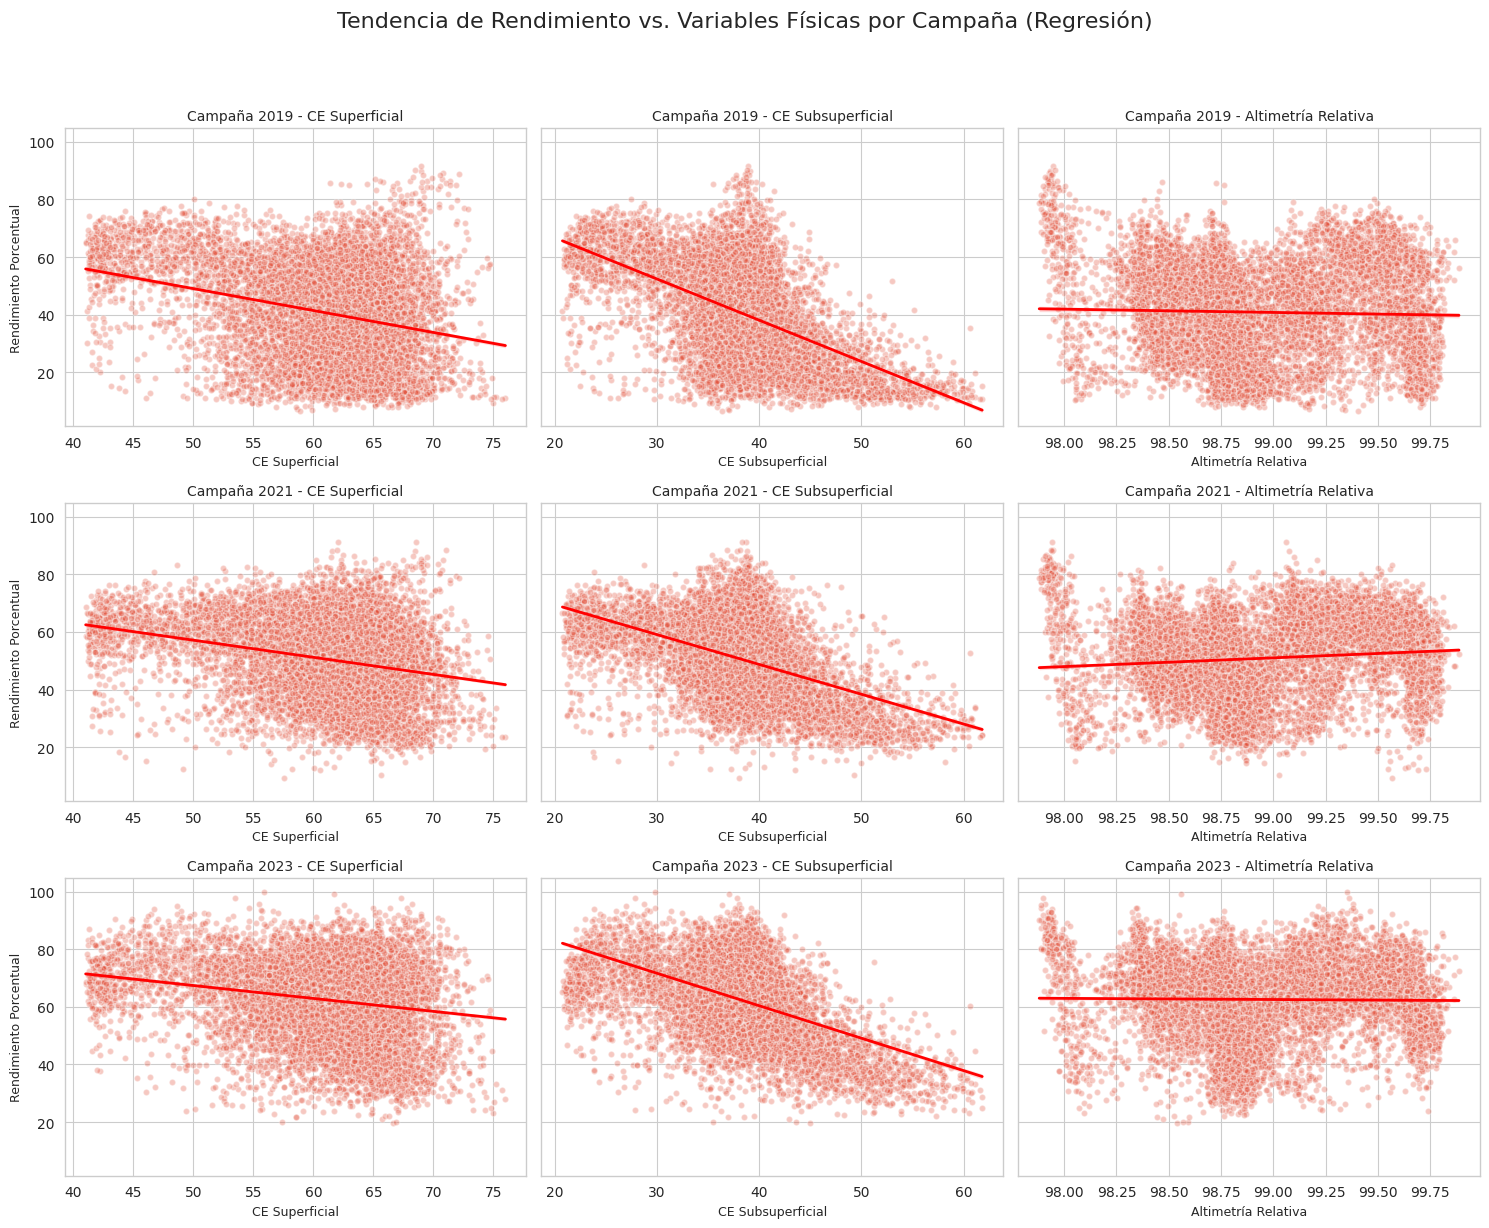

In [39]:
# Scatter plots Agrupados (3 Filas x 3 Columnas) con Línea de Tendencia

STATIC_VARS = ['ec_surface', 'ec_subsurface', 'altimetry_rel']
REN_COLS = ['performance_pct_2019', 'performance_pct_2021', 'performance_pct_2023']

df_largo_corr = gdf_final[STATIC_VARS + REN_COLS].copy().drop(columns=['geometry'], errors='ignore')

df_largo_corr = df_largo_corr.melt(
    id_vars=STATIC_VARS,
    value_vars=REN_COLS,
    var_name='Campaña_Col',
    value_name='Rendimiento_PCT'
).dropna(subset=['Rendimiento_PCT'])

df_largo_corr['Campaña'] = df_largo_corr['Campaña_Col'].str.extract(r'(\d{4})$')

df_largo_largo = df_largo_corr.melt(
    id_vars=['Campaña', 'Rendimiento_PCT'],
    value_vars=STATIC_VARS,
    var_name='Variable_Fisica',
    value_name='Valor'
)

# Mapear nombres internos a nombres legibles para títulos/ejes
VARIABLE_NAMES_MAP = {
    'ec_surface': 'CE Superficial',
    'ec_subsurface': 'CE Subsuperficial',
    'altimetry_rel': 'Altimetría Relativa'
}

# CREACIÓN DEL GRID MANUAL (3 FILAS x 3 COLUMNAS)

campañas_orden = ['2019', '2021', '2023']
variables_orden = STATIC_VARS

# Configuración del plot
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
fig.suptitle('Tendencia de Rendimiento vs. Variables Físicas por Campaña (Regresión)', y=1.02, fontsize=16)

for i, campaña in enumerate(campañas_orden):
    for j, var_fisica in enumerate(variables_orden):
        ax = axes[i, j]
        
        # Filtrar datos para la celda actual (Campaña x Variable)
        df_plot = df_largo_largo[
            (df_largo_largo['Campaña'] == campaña) & 
            (df_largo_largo['Variable_Fisica'] == var_fisica)
        ]
        
        # Usar sns.regplot para scatter + línea de tendencia
        sns.regplot(
            x='Valor', 
            y='Rendimiento_PCT', 
            data=df_plot, 
            ax=ax,
            scatter_kws={'alpha': 0.3, 's': 20, 'edgecolor': 'w'},
            line_kws={'color': 'red', 'lw': 2}
        )
        
        # Ajuste de títulos y ejes
        ax.set_title(f'Campaña {campaña} - {VARIABLE_NAMES_MAP[var_fisica]}', fontsize=10)
        ax.set_xlabel(VARIABLE_NAMES_MAP[var_fisica], fontsize=9)
        if j == 0:
            ax.set_ylabel('Rendimiento Porcentual', fontsize=9)
        else:
            ax.set_ylabel('') # Solo la primera columna necesita etiqueta Y

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Relación general entre las variables:
#### Los gráficos de dispersión y las matrices de correlación indican una relación negativa consistente entre la Conductividad Eléctrica (CE) "tanto superficial como subsuperficial" y el rendimiento. Esto sugiere que:
#### A mayor CE, menor rendimiento promedio.
#### El efecto es más fuerte en la CE subsuperficial, lo que indica que el comportamiento del suelo en profundidad (posiblemente asociado a sodicidad, compactación o limitaciones hídricas) tiene más peso que las condiciones superficiales.

#### Altimetría relativa:
#### La posición topográfica no explica directamente el rendimiento en este lote.
#### No es un factor limitante, o su efecto se puede estar enmascarado por otras variables más dominantes (efecto de colinealidad) como la CE subsuperficial

#### Dado que las correlaciones son consistentes entre campañas, es muy probable que, existan zonas o polígonos estables de bajo rendimiento que coinciden espacialmente con zonas de alta CE subsuperficial. 
#### Considerando que los datos de Suelo (rastra Veris) corresponden al año 2019, ese mapa de correlación es el más valioso. A nivel espacial ofrece la mejor segmentación para definir zonas de manejo, ya que te identifica de manera más nítida las áreas de alto y bajo potencial.

# ¿Puede identificar puntos críticos y puntos fríos espaciales en función del rendimiento de la campaña 2020-2021?


In [11]:
# Se instala en el notebook. No se incorporo a las dependencias del Dockerfile del contenedor de Python
!pip install libpysal esda contextily


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


#### Los hotspots de baja y alta productividad se pueden confirmar a travez de una autocorrelación espacial sobre los mapas de rendimiento por campaña.

/tmp/ipykernel_2515/4279132373.py:18: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf_lisa)


I de Moran Global: 0.7818 (p=0.0010)


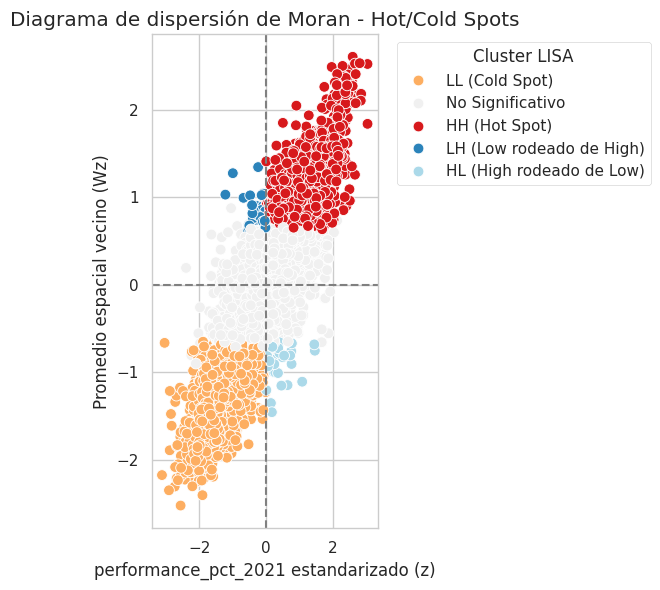

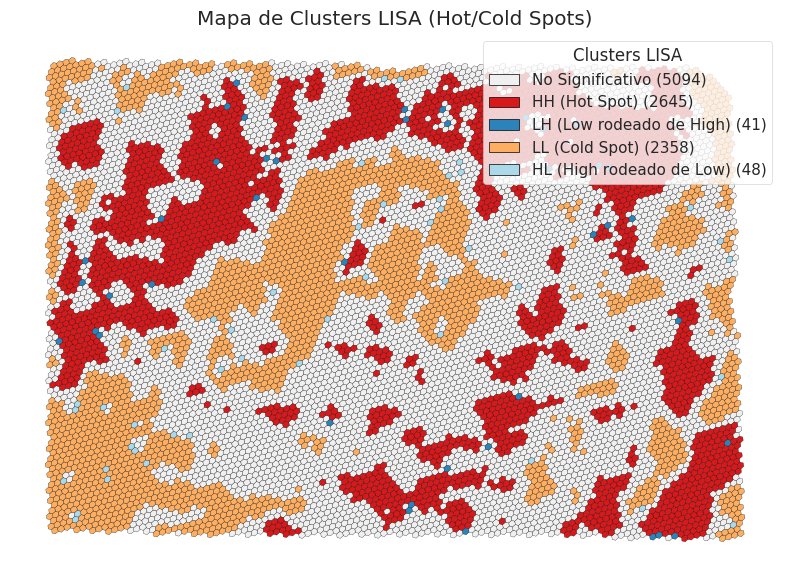


Resumen de agrupamientos LISA:
                    Cluster  Cantidad
0          No Significativo      5094
1             HH (Hot Spot)      2645
2            LL (Cold Spot)      2358
3  HL (High rodeado de Low)        48
4  LH (Low rodeado de High)        41


,ID,Variable,Promedio,Desvio,Varianza,Moran_Local_I,p_Local,Cluster_code,Cluster_label,Significativo,N_neighbors,Id_Hexagono,ec_surface,ec_subsurface,altimetry_rel,performance_pct_2019,performance_pct_2023
0,0,performance_pct_2021,50.727652,13.2997,176.882032,0.674836,0.046,3,LL (Cold Spot),True,6,8cc34d60575ebff,66.476359,47.033329,98.835411,18.664806,46.843324
1,1,performance_pct_2021,50.727652,13.2997,176.882032,0.138940,0.113,0,No Significativo,False,6,8cc34d601ce8dff,48.230089,26.083787,99.232450,54.956480,73.741463
2,2,performance_pct_2021,50.727652,13.2997,176.882032,0.012877,0.064,0,No Significativo,False,6,8cc34d600af5bff,64.236055,37.868192,98.392916,37.048183,68.562999
3,3,performance_pct_2021,50.727652,13.2997,176.882032,1.095280,0.075,0,No Significativo,False,6,8cc34d605393dff,53.556383,36.372514,99.183092,38.469078,70.937806
4,4,performance_pct_2021,50.727652,13.2997,176.882032,0.521030,0.091,0,No Significativo,False,6,8cc34d600a76dff,63.607454,39.711355,98.458970,53.486527,73.330362
5,5,performance_pct_2021,50.727652,13.2997,176.882032,0.079255,0.186,0,No Significativo,False,6,8cc34d6057b17ff,68.290244,43.506818,98.646524,35.547886,59.098266
6,6,performance_pct_2021,50.727652,13.2997,176.882032,0.080441,0.243,0,No Significativo,False,6,8cc34d6050c6bff,59.433388,41.197206,98.896453,40.330412,57.326633
7,7,performance_pct_2021,50.727652,13.2997,176.882032,0.167293,0.097,0,No Significativo,False,6,8cc34d60199cdff,60.313965,36.782509,99.314481,48.164189,68.070645
8,8,performance_pct_2021,50.727652,13.2997,176.882032,0.007879,0.447,0,No Significativo,False,6,8cc34d6057329ff,62.124873,40.077848,98.764741,30.260788,71.403927
9,9,performance_pct_2021,50.727652,13.2997,176.882032,0.171261,0.122,0,No Significativo,False,6,8cc34d6052961ff,63.386997,40.104479,99.146391,41.074903,63.375815


In [40]:
# Análisis de Puntos Críticos y Puntos Fríos (Hot/Cold Spots) - Campaña 2021
import libpysal, esda
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar datos
REN_COL_LISA = 'performance_pct_2021'
gdf_lisa = gdf_final.dropna(subset=[REN_COL_LISA]).reset_index(drop=True)
y = gdf_lisa[REN_COL_LISA]

# Otras Columnas adicionales
otras_vars = ['Id_Hexagono','ec_surface','ec_subsurface','altimetry_rel','performance_pct_2019','performance_pct_2023']

# 2. Matriz de pesos espaciales (Queen)
w = libpysal.weights.Queen.from_dataframe(gdf_lisa)
w.transform = 'r'

# 3. Moran Global
moran_global = esda.moran.Moran(y, w)
print(f"I de Moran Global: {moran_global.I:.4f} (p={moran_global.p_sim:.4f})")

# 4. Moran Local (LISA)
lisa = esda.moran.Moran_Local(y, w)

gdf_lisa['lisa_I'] = lisa.Is
gdf_lisa['lisa_p'] = lisa.p_sim
gdf_lisa['lisa_class'] = np.where(lisa.p_sim < 0.05, lisa.q, 0)

class_labels = {
    0: 'No Significativo',
    1: 'HH (Hot Spot)',
    2: 'LH (Low rodeado de High)',
    3: 'LL (Cold Spot)',
    4: 'HL (High rodeado de Low)'
}
class_colors = {
    'No Significativo':'#f0f0f0',
    'HH (Hot Spot)':'#d7191c',
    'LH (Low rodeado de High)':'#2b83ba',
    'LL (Cold Spot)':'#fdae61',
    'HL (High rodeado de Low)':'#abd9e9'
}

gdf_lisa['lisa_label'] = gdf_lisa['lisa_class'].map(class_labels)
gdf_lisa['lisa_color'] = gdf_lisa['lisa_label'].map(class_colors)

# 5. Moran Scatterplot
z = (y - y.mean()) / y.std()
wz = libpysal.weights.spatial_lag.lag_spatial(w, z)

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=z, y=wz, hue=gdf_lisa['lisa_label'], 
    palette=class_colors, s=60
)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel(f"{REN_COL_LISA} estandarizado (z)")
plt.ylabel("Promedio espacial vecino (Wz)")
plt.title("Diagrama de dispersión de Moran - Hot/Cold Spots")
plt.legend(title='Cluster LISA', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# 6. Mapa de Clusters LISA
# Contar cantidad de polígonos por cluster
fig, ax = plt.subplots(figsize=(8,8))

# Contar cantidad de polígonos por cluster
cluster_counts = gdf_lisa['lisa_label'].value_counts().to_dict()

# Dibujar cada cluster
for label, color in class_colors.items():
    subset = gdf_lisa[gdf_lisa['lisa_label'] == label]
    subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.2)

# Crear leyenda manual
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=color, edgecolor='black', 
          label=f"{label} ({cluster_counts.get(label,0)})")
    for label, color in class_colors.items()
]
ax.legend(handles=legend_handles, title="Clusters LISA", loc='upper right')

ax.set_axis_off()
plt.title("Mapa de Clusters LISA (Hot/Cold Spots)")
plt.tight_layout()
plt.show()

# 7. Tabla
tabla_lisa = pd.DataFrame({
    'ID': gdf_lisa.index.astype(str),
    'Variable': REN_COL_LISA,
    'Promedio': y.mean(),
    'Desvio': y.std(),
    'Varianza': y.var(),
    'Moran_Local_I': gdf_lisa['lisa_I'],
    'p_Local': gdf_lisa['lisa_p'],
    'Cluster_code': gdf_lisa['lisa_class'],
    'Cluster_label': gdf_lisa['lisa_label'],
    'Significativo': gdf_lisa['lisa_class'] != 0,
    'N_neighbors': [len(w.neighbors[i]) for i in range(len(gdf_lisa))]
})

# Anexar columnas
tabla_lisa = pd.concat([tabla_lisa, gdf_lisa[otras_vars].reset_index(drop=True)], axis=1)

# 8. Resumen por cluster
resumen_clusters = gdf_lisa['lisa_label'].value_counts().reset_index()
resumen_clusters.columns = ['Cluster', 'Cantidad']
print("\nResumen de agrupamientos LISA:")
print(resumen_clusters)

tabla_lisa.head(10)



Valores faltantes por columna:
Id_Hexagono              0
ec_surface              40
ec_subsurface           40
altimetry_rel           40
performance_pct_2019    15
performance_pct_2023    34
Cluster_label            0
dtype: int64

Resumen descriptivo por cluster:


ec_surface                                  \
                               mean       std        min        max   
lisa_label                                                            
HH (Hot Spot)             57.295087  7.252768  41.131478  72.713620   
HL (High rodeado de Low)  61.770522  3.595089  55.273688  69.369972   
LH (Low rodeado de High)  57.316756  7.430406  41.380327  70.237632   
LL (Cold Spot)            62.885871  4.971591  41.536161  75.995399   
No Significativo          61.443493  5.431276  41.037771  74.746267   

                         ec_subsurface                                  \
                                  mean       std        min        max   
lisa_label                                                               
HH (Hot Spot)                34.202702  5.630601  20.767299  50.050636   
HL (High rodeado de Low)     42.370706  5.890386  34.152725  60.571606   
LH (Low rodeado de High)     34.031069  5.887057  21.526057  42.348708   
LL (Cold Spot)               43.221449  6.966788  21.189000  61.804348   
No Significativo             37.584947  4.352978  20.876365  55.436412   

                         altimetry_rel                                  
                                  mean       std        min        max  
lisa_label                                                              
HH (Hot Spot)                99.033474  0.501972  97.880814  99.827020  
HL (High rodeado de Low)     98.898564  0.357995  98.008509  99.769237  
LH (Low rodeado de High)     99.051684  0.506315  97.913405  99.654263  
LL (Cold Spot)               98.860924  0.349940  97.977518  99.804881  
No Significativo             98.882201  0.409288  97.933072  99.887399

/tmp/ipykernel_2515/3337540556.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='lisa_label', y=var, data=gdf_lisa, palette=class_colors, order=class_colors.keys())


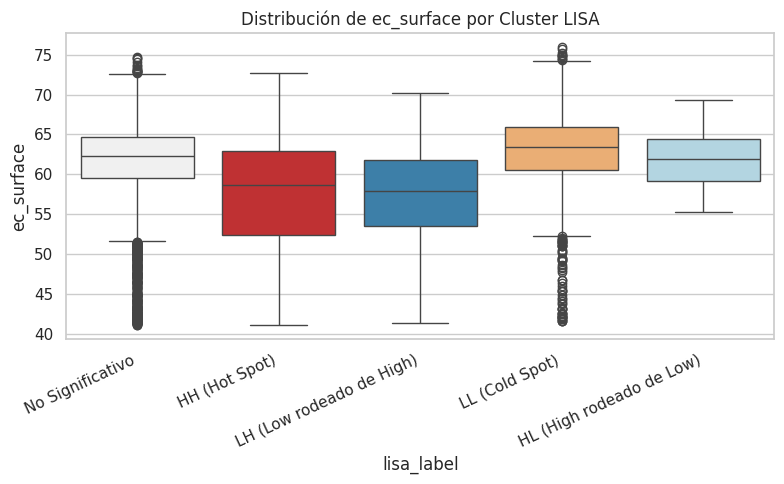

/tmp/ipykernel_2515/3337540556.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='lisa_label', y=var, data=gdf_lisa, palette=class_colors, order=class_colors.keys())


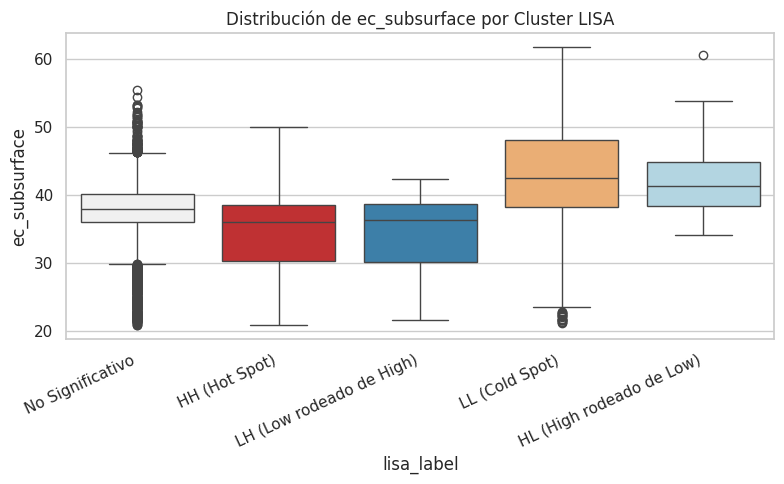

/tmp/ipykernel_2515/3337540556.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='lisa_label', y=var, data=gdf_lisa, palette=class_colors, order=class_colors.keys())


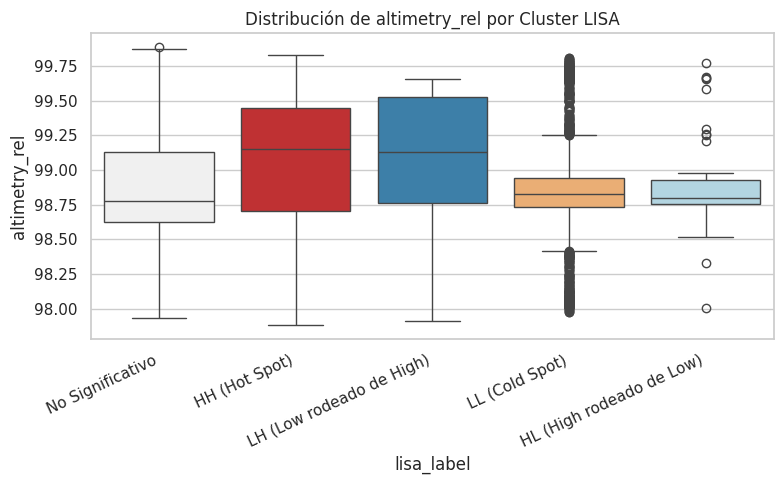


Resultados T-test (HH vs LL):


,Variable,T-Statistic,P-Valor
0,ec_surface,-31.107,0.0
1,ec_subsurface,-48.811,0.0
2,altimetry_rel,13.793,0.0



Resultados ANOVA:


,Variable,F-Statistic,P-Valor
0,ec_surface,313.438,0.0
1,ec_subsurface,867.162,0.0
2,altimetry_rel,66.587,0.0



Interpretación:
 ec_surface: diferencia significativa entre HH y LL (p=0.0)
 ec_subsurface: diferencia significativa entre HH y LL (p=0.0)
 altimetry_rel: diferencia significativa entre HH y LL (p=0.0)


In [34]:
# Explorando relaciones estadísticas para ver si los hotspots (HH) o coldspots (LL) se asocian con ciertas características del suelo o altimetría:

# 7. Datos faltantes
print("\nValores faltantes por columna:")
print(tabla_lisa[otras_vars + ['Cluster_label']].isna().sum())

# 8. Estadísticas descriptivas por cluster
resumen_edafico = gdf_lisa.groupby('lisa_label')[['ec_surface', 'ec_subsurface', 'altimetry_rel']].agg(['mean','std','min','max'])
print("\nResumen descriptivo por cluster:")
display(resumen_edafico)

# 9. Boxplots comparativos
sns.set(style="whitegrid", palette="muted")

for var in ['ec_surface', 'ec_subsurface', 'altimetry_rel']:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='lisa_label', y=var, data=gdf_lisa, palette=class_colors, order=class_colors.keys())
    plt.title(f"Distribución de {var} por Cluster LISA")
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

# 10. T-test (HH vs LL) y ANOVA (todos los clusters)
def robust_ttest(df, var, grupo_col='lisa_label', g1='HH (Hot Spot)', g2='LL (Cold Spot)'):
    g1_vals = df[df[grupo_col]==g1][var].dropna()
    g2_vals = df[df[grupo_col]==g2][var].dropna()
    if len(g1_vals)>1 and len(g2_vals)>1 and g1_vals.std()>0 and g2_vals.std()>0:
        ttest = ttest_ind(g1_vals, g2_vals, equal_var=False)
        return round(ttest.statistic,3), round(ttest.pvalue,5)
    else:
        return np.nan, np.nan

resultados_ttest = []
for var in ['ec_surface', 'ec_subsurface', 'altimetry_rel']:
    stat, pval = robust_ttest(gdf_lisa, var)
    resultados_ttest.append({'Variable': var, 'T-Statistic': stat, 'P-Valor': pval})

df_ttest = pd.DataFrame(resultados_ttest)
print("\nResultados T-test (HH vs LL):")
display(df_ttest)

resultados_anova = []
for var in ['ec_surface', 'ec_subsurface', 'altimetry_rel']:
    grupos = [vals.dropna() for _, vals in gdf_lisa.groupby('lisa_label')[var]]
    grupos = [g for g in grupos if len(g)>1]
    if len(grupos) > 1:
        anova = f_oneway(*grupos)
        resultados_anova.append({'Variable': var,
                                 'F-Statistic': round(anova.statistic,3),
                                 'P-Valor': round(anova.pvalue,5)})
    else:
        resultados_anova.append({'Variable': var, 'F-Statistic': np.nan, 'P-Valor': np.nan})

df_anova = pd.DataFrame(resultados_anova)
print("\nResultados ANOVA:")
display(df_anova)

# 11. Interpretación
print("\nInterpretación:")
for _, row in df_ttest.iterrows():
    if pd.notna(row['P-Valor']):
        if row['P-Valor'] < 0.05:
            print(f" {row['Variable']}: diferencia significativa entre HH y LL (p={row['P-Valor']})")
        else:
            print(f" {row['Variable']}: sin diferencia significativa (p={row['P-Valor']})")


### Las variables del suelo explican en gran medida la distribución espacial del rendimiento.
### Las zonas HH tienden a estar asociadas a suelo con mejor conductividad y altimetría favorable, mientras que las LL aparecen en ambientes restrictivos o con limitaciones.

#### La Clasificación LISA (Cluster Map): define el tipo de agrupación espacial:

##### 1: High-High (HH) -> Hot Spots (Puntos Críticos, Rendimiento Alto rodeado de Alto): zonas de alto potencial
##### 2: Low-Low (LL) -> Cold Spots (Puntos Fríos, Rendimiento Bajo rodeado de Bajo): zonas de bajo potencial 
##### 3: Low-High (LH) -> Outliers (Rendimiento Bajo rodeado de Alto): se consideran Inliers (outliers espaciales)
##### 4: High-Low (HL) -> Outliers (Rendimiento Alto rodeado de Bajo): se consideran Inliers (outliers espaciales)
##### 5: No Significativo -> Son zonas promedio, el rendimieno se distribuye de manera aleatoria. "La diferencia con sus vecinos no es significativa" 

##### Los valores de Performance de Soja al estar Normalizados se los considero como mapas listos para la etapa de analisis. Paso previo a la Normalizacion considero que se tiene que revisar muy bien los datos ya que los mapas llegan con mucho ruido y mas aún si provienen de maquinas diferentes. Considero que se tienen que aplicar una limpieza general de Outliers (globales), Inliers (outliers espaciales) y un modelo de interpolacion ajustado.


## ¿Cuál podría ser la razón de la baja productividad en las áreas con peor rendimiento? ¿Podría sugerir alguna acción en colaboración con el equipo de campo para mejorar el rendimiento en estas áreas?

## La razón principal de la baja productividad persistente en las áreas clasificadas como Cold Spots (LL) es la combinación de factores edáficos estructurales permanentes que actúan como una restricción severa, especialmente en años de estrés climático
#### En base al analisis previo:
#### La alta conductividad eléctrica subsuperficial (CE_sub), la fuerte correlación negativa (~ -0.48), son indicios de suelos más arcillosos, con menor porosidad, más compactación o drenaje deficiente. Estas condiciones limitan el crecimiento radicular y hace menos accesible para las plantas incorporar nutrientes y agua (exceso/defecto).
#### Altimetria: aunque el efecto fue leve, las zonas mas bajas tienden acumular agua y sales, agravando los problemas. El exceso hídrico reduce oxigenación en el perfil radicular.

#### Considerando que extrapolamos los resultados de la capa de "veris_data" para las tres campañas, se puede ver una persistencia temporal del patron solo entendiendo las realaciones espaciales. La estructura espacial entre campañas se repite, lo que se considera que la causa es edáfica o estructural, no climatica o de manejo puntual.

#### Recomendaciones Tácticas para el Equipo de Campo:

#### A. Diagnóstico Fino de Suelos:
#### Muestreos Dirigidos por Zonas: utilizar los mapas de Cold Spots (LL) y Hot Spots (HH) generados por los analistas para definir un plan metodológico de muestreo preciso.
#### Comparar Propiedades Físico-Químicas: analizar de forma contrastada la textura, Materia Orgánica (MO), compactación (con penetrómetro) y presencia de sales/sodio en ambas zonas (LL vs. HH) para identificar el factor limitante específico.

#### B. Mejorar la Estructura y el Drenaje (Soluciones Edáficas)
#### Descompactación Localizada: la CE sub y el penetrómetro sugieren problemas de estructura. Realizar una descompactación con equipos VRT (Tasa Variable) solo en las zonas LL que lo requieran (donde la compactación o CE sub sean altas).
#### Manejo de Sales o Drenaje: la baja altimetría implica riesgo de anegamiento. Si el diagnóstico lo confirma, aplicar yeso agrícola de forma localizada para corregir la sodicidad.

#### C. Manejo Agronómico (Optimización de Insumos):
#### Manejo de Fertilización Variable: aplicar insumos con criterio agronómico diferenciado. Reducir la inversión en los Puntos Fríos (LL) y optimizarla en los Puntos Críticos (HH), maximizando la eficiencia de capital.
#### Rotaciones Estratégicas: introducir gramíneas o cultivos de cobertura en las zonas LL para mejorar la estructura del suelo y el contenido de MO a largo plazo, mitigando la compactación de forma biológica.

#### D. Capacitación: la capacitación del personal técnico y operativo es lo más importante para el éxito. Hoy, con tanta tecnología aplicada, la transferencia del conocimiento del análisis a la ejecución en la máquina debe ser un proceso continuo.


# ... Acá podria considerar las realciones del mapa con las otras variables (conductividad super, subper, altimetria). BUSCAR ALGUN ANALISIS O RELACION ESTADISTICA QUE PERMITE VER ESE SOLAPAMIENTO